In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

# BB84 Quantum Key Distribution — With Attacker (Eve)

This notebook simulates BB84 **in the presence of an eavesdropper, Eve**, who performs an **intercept-resend attack**: she intercepts each qubit Alice sends, measures it in a randomly chosen basis, and resends a new qubit reflecting her measurement result.

## Why Eve is detectable

The **No-Cloning Theorem** prevents Eve from copying a qubit. When she measures in the *wrong* basis, she destroys the original state and resends a disturbed qubit. This introduces errors in Bob's results even at positions where Alice and Bob used the **same** basis. Alice and Bob detect this by publicly comparing a **sample** of their shared key bits — a high error rate reveals Eve.

A random intercept-resend attack causes about 25% errors in the sifted bits: Eve chooses the wrong basis about half the time, and when she does, Bob has about a 50% chance of receiving the wrong bit.

In [2]:
# Setup
simulator = BasicSimulator()

# Number of qubits Alice sends
N = 50

# If error rate exceeds this, they abort
ERROR_THRESHOLD  = 0.15

print(f"N={N} qubits, error threshold={ERROR_THRESHOLD}")

N=50 qubits, error threshold=0.15


## Choice of Number of Qubits and Threshold

The value of `N` is not fixed by BB84. In this attacker simulation, `N = 50` is used instead of the smaller no-attacker example because attack detection is statistical. After basis sifting, only about half of the qubits remain, and then some of those sifted bits are sacrificed for checking. A larger `N` gives a more meaningful estimate of Eve's error rate while keeping the notebook output readable.

The threshold `ERROR_THRESHOLD = 0.15` means Alice and Bob abort if more than 15% of the checked sample bits disagree. This is below the expected intercept-resend error rate of about 25%, so Eve is likely to be detected. In real systems, this threshold would need to balance detection sensitivity against false positives caused by normal channel noise.

## Quantum Random Number Generation

Below function is generated via preparing *n* qubits in the state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and measuring each one. This is used instead of `random.randint()` because BB84 is a quantum protocol. Measuring a qubit prepared in the superposition state $|+\rangle$ gives outcome `0` or `1` with equal probability, and the result is produced by quantum measurement rather than by a classical pseudo-random algorithm.

In [3]:
def quantum_random_bit():
  """
  Generate one truly random bit by preparing |+⟩ = (|0⟩+|1⟩)/√2
  and measuring it.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

def quantum_random_bits(n):
  """Generate n random bits by calling quantum_random_bit() n times."""
  return [quantum_random_bit() for _ in range(n)]

# Quick sanity check
sample = quantum_random_bits(10)
print("Sample quantum random bits:", sample)

Sample quantum random bits: [0, 0, 0, 1, 1, 0, 0, 0, 0, 1]


## Alice Part

Alice generates random data bits and random basis choices. She then encodes each bit as a qubit using the following encoding rule:

- Standard basis (basis=0):  $0 \rightarrow |0\rangle$,  $1 \rightarrow |1\rangle$
- Diagonal basis (basis=1):  $0 \rightarrow |+\rangle$,  $1 \rightarrow |-\rangle$

In this attacker version, Alice sends the prepared qubits into the quantum channel, where Eve may intercept and measure them before they reach Bob.

In [4]:
alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def encoding_circuit(bit, basis):
    """Return Alice's 1-qubit encoding circuit without measurement."""
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

def alice_prepare_qubit(bit, basis):
    """
    Prepare a qubit encoding `bit` in `basis`.

    Standard (basis=0):  0 -> |0> (no gate)   1 -> |1> (X gate)
    Diagonal (basis=1):  0 -> |+> (H gate)    1 -> |-> (X then H)
    """
    qc = QuantumCircuit(1, 1)
    qc.compose(encoding_circuit(bit, basis), inplace=True)
    return qc

# Alice sends qubits into the quantum channel (where Eve is waiting)
alice_channel = [alice_prepare_qubit(alice_bits[i], alice_bases[i]) for i in range(N)]

print("=== ALICE ===")
print(f"Bits:  {alice_bits[:20]} ... (showing first 20)")
print(f"Bases: {['S' if b==0 else 'D' for b in alice_bases[:20]]} ...")
print(f"\nAlice has prepared {N} qubits and sent them into the channel.")

=== ALICE ===
Bits:  [1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1] ... (showing first 20)
Bases: ['D', 'D', 'D', 'S', 'D', 'D', 'D', 'D', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'D', 'S'] ...

Alice has prepared 50 qubits and sent them into the channel.


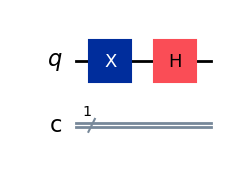

In [5]:
# Show Alice's first prepared qubit as a circuit diagram.
inspection_index = 0
alice_example = alice_channel[inspection_index]
alice_example.draw("mpl")

In [6]:
# Calculate the state from |0> and display it symbolically.
# Uses the measurement-free version of Alice's same bit and basis.
alice_unitary_example = encoding_circuit(alice_bits[inspection_index], alice_bases[inspection_index])
state = Statevector.from_int(0, 2)
state = state.evolve(alice_unitary_example)
state.draw("latex")

<IPython.core.display.Latex object>

In [7]:
U = Operator(alice_unitary_example)
array_to_latex(U)

<IPython.core.display.Latex object>

## Eve (Attacker) — Intercept-Resend Attack

Eve intercepts every qubit Alice sends.

For each qubit:
1. A random measurement basis is selected (Alice's choice is unknown).
2. Qubit in that basis is measured — this irreversibly collapses the quantum state (the No-Cloning Theorem prevents copying of qubit while keeping the original).
3. A fresh qubit is prepared to match the her measurement result and forwards it to Bob.


### Outcomes
When Eve guesses the **SAME** basis as Alice: she gets the right bit and Bob receives the correct state — no disruption.

When Eve guesses the **WRONG** basis: her measurement gives a random result and she forwards a disturbed state. If Alice and Bob happen to use the same basis for that qubit, Bob will still get the wrong bit ~50% of those cases → overall ~25% error rate in the shared key.

In [8]:
eve_bases = quantum_random_bits(N)

def eve_intercept_and_resend(qubit_circuit, eve_basis):
    """
    Eve intercepts `qubit_circuit`, measures it in `eve_basis`,
    and returns a freshly prepared qubit matching her measurement result.

    This simulates the No-Cloning constraint: Eve cannot copy the unknown
    qubit, so she must measure it and then resend a new qubit to Bob.
    """
    # Eve Measure
    qc = qubit_circuit.copy()
    if eve_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    eve_bit = int(list(result.get_counts().keys())[0])

    # Resends a fresh qubit matching her measurement
    new_qc = QuantumCircuit(1, 1)
    if eve_bit == 1:
        new_qc.x(0)
    if eve_basis == 1:
        new_qc.h(0)
    return new_qc

# Eve sits on the channel and tampers with all N qubits
eve_channel = [eve_intercept_and_resend(alice_channel[i], eve_bases[i]) for i in range(N)]

print("=== EVE ===")
print(f"Bases: {['S' if b==0 else 'D' for b in eve_bases[:20]]} ...")
print(f"\nEve has intercepted all {N} qubits, measured them, and resent fresh qubits to Bob.")

=== EVE ===
Bases: ['D', 'D', 'D', 'D', 'S', 'S', 'D', 'S', 'S', 'S', 'S', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'D', 'D'] ...

Eve has intercepted all 50 qubits, measured them, and resent fresh qubits to Bob.


### Eve Circuit Inspection

Eve has two useful circuit views.

The first inspection circuit shows Eve's measurement step. Eve takes Alice's incoming qubit, optionally changes basis using `H`, and measures it. This measurement collapses the original quantum state.

The second inspection circuit shows only the fresh qubit that Eve prepares and sends onward to Bob. It does not contain Alice's original state because Eve cannot copy and forward the original qubit after measuring it. This is the key disturbance introduced by the intercept-resend attack.

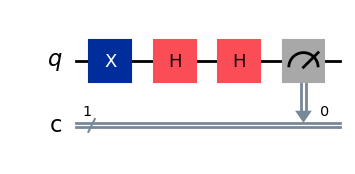

In [9]:
eve_measurement_example = alice_channel[inspection_index].copy()
if eve_bases[inspection_index] == 1:
    eve_measurement_example.h(0)
eve_measurement_example.measure(0, 0)
eve_measurement_example.draw("mpl")

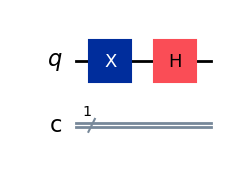

In [10]:
eve_resend_example = eve_channel[inspection_index]
eve_resend_example.draw("mpl")

## Bob Part

Bob receives qubits from the channel and measures them without knowing whether Eve has interfered. In the no-attacker version, Bob receives Alice's original prepared qubits. In this attacker version, Bob receives the fresh qubits resent by Eve after her measurement.

Bob still follows the normal BB84 procedure: he randomly chooses a basis for each qubit, applies `H` first if measuring in the diagonal basis, and then measures. If Eve used the wrong basis when intercepting, the qubit Bob receives may already be disturbed, so Bob can get a different bit from Alice even when Bob and Alice later discover that they used the same basis.

In [11]:
bob_bases = quantum_random_bits(N)

def bob_measure_qubit(qubit_circuit, basis):
    """Bob measures the received qubit in his chosen basis."""
    qc = qubit_circuit.copy()
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    return int(list(result.get_counts().keys())[0])

# Bob measures from Eve's tampered channel (he thinks it's Alice's)
bob_bits = [bob_measure_qubit(eve_channel[i], bob_bases[i]) for i in range(N)]

print("=== BOB ===")
print(f"Bases: {['S' if b==0 else 'D' for b in bob_bases[:20]]} ...")
print(f"Bits:  {bob_bits[:20]} ...")

=== BOB ===
Bases: ['D', 'D', 'S', 'S', 'S', 'D', 'D', 'D', 'S', 'S', 'S', 'S', 'S', 'D', 'D', 'S', 'S', 'D', 'S', 'S'] ...
Bits:  [1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0] ...


### Bob Measurement Circuit Inspection

Bob receives Eve's resent qubit, applies his basis choice, and measures. Since this circuit contains measurement, it is best viewed as a circuit diagram rather than converted to a statevector or unitary matrix.

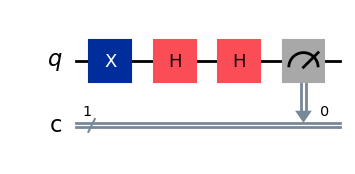

In [12]:
bob_measurement_example = eve_channel[inspection_index].copy()
if bob_bases[inspection_index] == 1:
    bob_measurement_example.h(0)
bob_measurement_example.measure(0, 0)
bob_measurement_example.draw("mpl")

## Public Channel: Basis Sifting

Alice and Bob will compare their basis choices. They keep only the positions where same basis is used.

Eve may observe this public basis comparison, but it does not reveal the secret key because Alice and Bob announce only their bases, not their bit values. Eve can learn which of her measurements correspond to retained positions, but she still does not know whether her measured bit was correct when she chose the wrong basis.

In [13]:
matching_indices = [i for i in range(N) if alice_bases[i] == bob_bases[i]]

alice_sifted = [alice_bits[i] for i in matching_indices]
bob_sifted   = [bob_bits[i]   for i in matching_indices]

print("=== PUBLIC CHANNEL: BASIS COMPARISON ===")
print(f"Total qubits    : {N}")
print(f"Basis matches   : {len(matching_indices)}")
print(f"Sifted key len  : {len(alice_sifted)} bits")

=== PUBLIC CHANNEL: BASIS COMPARISON ===
Total qubits    : 50
Basis matches   : 24
Sifted key len  : 24 bits


## Attack Detection: Error Rate Check

Alice and Bob publicly compare a **random sample** of their sifted bits. These sample bits are sacrificed: once they are revealed, they are not used in the final key.

The sample positions are chosen using `quantum_random_bits()` rather than a classical random number generator. This keeps the sampling step consistent with the quantum-random choices used elsewhere in the protocol.

Alice and Bob calculate the error rate in the sample. If this rate exceeds `ERROR_THRESHOLD`, the notebook reports an attack and aborts the key.



In [14]:
n_sifted = len(alice_sifted)

# Use quantum randomness to decide which sifted bits to sacrifice for checking.
mask = quantum_random_bits(n_sifted)
sample_indices = [i for i, m in enumerate(mask) if m == 1]
# If the random mask selects no check bits, sacrifice one sifted bit so the attack-detection sample is not empty.
if n_sifted > 0 and not sample_indices:
    sample_indices = [0]

sample_index_set = set(sample_indices)
key_indices = [i for i in range(n_sifted) if i not in sample_index_set]

# Compare sample bits over public channel
alice_sample = [alice_sifted[i] for i in sample_indices]
bob_sample   = [bob_sifted[i]   for i in sample_indices]

n_sample     = len(alice_sample)
errors       = sum(a != b for a, b in zip(alice_sample, bob_sample))
error_rate   = errors / n_sample if n_sample > 0 else 0

print("=== ATTACK DETECTION ===")
print(f"Sample size     : {n_sample} bits")
print(f"Errors found    : {errors}")
print(f"Error rate      : {error_rate:.1%}")
print(f"Threshold       : {ERROR_THRESHOLD:.1%}")
print()

attack_detected = error_rate > ERROR_THRESHOLD

if attack_detected:
    print(f"ATTACK DETECTED! Error rate {error_rate:.1%} exceeds threshold {ERROR_THRESHOLD:.1%}.")
    print("   Alice and Bob ABORT - the channel is compromised.")
    print("   Eve's intercept-resend attack introduced errors because measurement disturbed some qubits.")
else:
    print(f"No attack detected. Error rate {error_rate:.1%} is within threshold.")
    print("   This can happen by chance if the sample is small; larger N improves confidence.")

=== ATTACK DETECTION ===
Sample size     : 14 bits
Errors found    : 4
Error rate      : 28.6%
Threshold       : 15.0%

ATTACK DETECTED! Error rate 28.6% exceeds threshold 15.0%.
   Alice and Bob ABORT - the channel is compromised.
   Eve's intercept-resend attack introduced errors because measurement disturbed some qubits.


## Key Extraction (if not aborted)

If Alice and Bob decide to proceed, they use only the sifted bits that were not sacrificed for attack checking.

The checking sample is normally selected by the quantum-random mask. If that mask accidentally selects no sample bits, the code forces one sifted bit into the checking sample so the error-rate test is not empty. That bit is also removed from the remaining key.

The key comparison below is included only for analysis. In a real BB84 protocol, Alice and Bob would not publicly compare the remaining key bits, because doing so would reveal the key. Here, the comparison helps show that Eve's attack may also corrupt the untested remaining bits.

*Note: with Eve present, these remaining bits will contain ~25% errors, making the key unreliable — which is why aborting is correct.*


In [15]:
alice_key = [alice_sifted[i] for i in key_indices]
bob_key = [bob_sifted[i]   for i in key_indices]

key_errors    = sum(a != b for a, b in zip(alice_key, bob_key))
key_error_rate = key_errors / len(alice_key) if alice_key else 0

print("=== KEY COMPARISON (for analysis) ===")
print(f"Remaining key length : {len(alice_key)} bits")
print(f"Key errors           : {key_errors}  ({key_error_rate:.1%} error rate)")
print()
print("Alice's key:", alice_key[:30], "..." if len(alice_key) > 30 else "")
print("Bob's key:  ", bob_key[:30],   "..." if len(bob_key) > 30 else "")
print()
print(f"Note: the {key_error_rate:.1%} key error rate confirms Eve's intercept-resend attack was active.")
print("Alice and Bob should have aborted — their 'shared key' is corrupted.")

=== KEY COMPARISON (for analysis) ===
Remaining key length : 10 bits
Key errors           : 2  (20.0% error rate)

Alice's key: [1, 0, 0, 0, 1, 0, 1, 1, 1, 1] 
Bob's key:   [1, 0, 0, 0, 0, 1, 1, 1, 1, 1] 

Note: the 20.0% key error rate confirms Eve's intercept-resend attack was active.
Alice and Bob should have aborted — their 'shared key' is corrupted.


The sample error rate and the remaining key error rate may be different because they are calculated from different random subsets of the sifted bits. The sample bits are sacrificed for attack detection, while the remaining bits are the candidate key bits.

In a real BB84 protocol, Alice and Bob would not publicly compare the remaining key bits, because doing so would reveal the key. This comparison is included only for simulation analysis, where both Alice's and Bob's full bit lists are available.

## Bob Measurement Histogram

The histogram below measures each transmitted qubit once, hence it aggregates Bob's observed classical outcomes after Eve's intercept-resend attack. It is a measurement-count summary, not the attack-detection error rate.

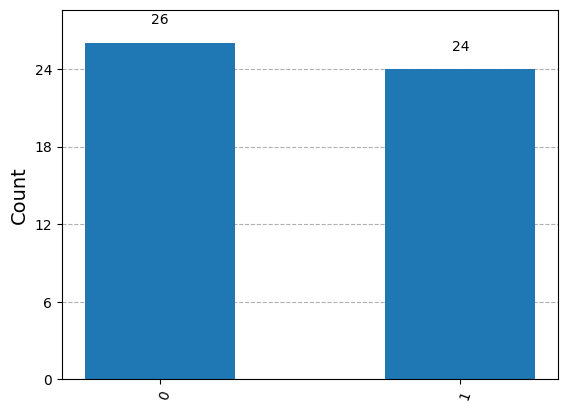

In [16]:
bob_measurement_counts = {
    "0": bob_bits.count(0),
    "1": bob_bits.count(1),
}
plot_histogram(bob_measurement_counts)

## Summary

The summary brings together the main security result of the attacker simulation. Eve's intercept-resend attack introduces errors into the sifted bits because she sometimes measures in the wrong basis and resends a disturbed qubit. When the checked sample error rate exceeds the threshold, `attack_detected = True`, so Alice and Bob should abort instead of using the remaining key.

The key error rate shown here is included only for analysis. It demonstrates that even the untested remaining bits may be corrupted when Eve is present.

In [17]:
print("===== BB84 PROTOCOL SUMMARY (With Attacker) =====")
print(f"  Qubits sent by Alice         : {N}")
print(f"  Basis matches (sifted)       : {len(matching_indices)}")
print(f"  Sample bits checked          : {n_sample}")
print(f"  Sample error rate            : {error_rate:.1%}  (expected ~25% with Eve)")
print(f"  Attack detected              : {attack_detected}")
print(f"  Key error rate (if used)     : {key_error_rate:.1%}")
print()
print("Security guarantee: the No-Cloning Theorem ensures Eve cannot intercept qubits without disturbing them, making her presence detectable.")

===== BB84 PROTOCOL SUMMARY (With Attacker) =====
  Qubits sent by Alice         : 50
  Basis matches (sifted)       : 24
  Sample bits checked          : 14
  Sample error rate            : 28.6%  (expected ~25% with Eve)
  Attack detected              : True
  Key error rate (if used)     : 20.0%

Security guarantee: the No-Cloning Theorem ensures Eve cannot intercept qubits without disturbing them, making her presence detectable.
